<a href="https://colab.research.google.com/github/Doclikam/Beijing-Multi-Site-Air-Quality-Data-Data-Set/blob/main/Notebooks/Iot_monitoring_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Iot Health Monitoring Project**

In [121]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from warnings import filterwarnings
filterwarnings('ignore')
import joblib
from datetime import date
import datetime as dt
import hashlib
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest


In [122]:
from sklearn.ensemble import IsolationForest

In [123]:
#load data
df_monitoring = pd.read_csv("/content/iot_health_monitoring_dataset.csv")
df_monitoring.head()

,timestamp,device_id,patient_id,heart_rate,blood_oxygen,blood_pressure_systolic,blood_pressure_diastolic,glucose_level,body_temperature,respiratory_rate,activity_level,sleep_quality,stress_level,hrv_sdnn,steps_count,calories_burned,health_event
0,2025-09-30 13:06:45.056387,DEVICE_0040,PATIENT_0310,88.7,91.9,178.0,100.0,131.1,97.66,23.3,0.486,0.215,0.778,12.7,2189,2033,3
1,2025-09-30 13:30:45.056387,DEVICE_0078,PATIENT_0147,82.3,96.5,122.0,82.0,57.7,98.89,19.9,0.650,0.671,0.296,58.1,11342,2634,0
2,2025-09-30 13:46:45.056387,DEVICE_0013,PATIENT_0129,101.7,91.3,139.0,102.0,143.4,98.89,26.5,0.490,0.395,0.772,17.2,3456,2157,3
3,2025-09-30 13:48:45.056387,DEVICE_0085,PATIENT_0470,73.9,98.3,121.0,88.0,108.5,98.73,16.5,0.445,0.707,0.339,97.2,8300,1631,0
4,2025-09-30 14:15:45.056387,DEVICE_0055,PATIENT_0245,75.7,93.0,109.0,81.0,109.2,98.74,14.2,0.612,0.844,0.197,64.1,7337,2498,0


In [124]:
#number of patients
df_monitoring.shape

(5094, 17)

# **Data preprocessing**

In [125]:
ID_COLS = ['device_id', 'patient_id']

VITAL_COLS = [
    'heart_rate',
    'blood_oxygen',
    'body_temperature',
    'respiratory_rate'
]

"""
these vital signs acan point to  anumber of health concerns, such as infections, hypoxia, shock, or cardiorespiratory conditions
we will asses if the abnomalities in these signs are transient or sustained(indicate disease pathology)
"""

CARDIO_METABOLIC_COLS = [
    'blood_pressure_systolic',
    'blood_pressure_diastolic',
    'glucose_level',
    'hrv_sdnn'
]
""" these can point to the existence of chronic conditions such as diabteds, hypertensiomn
they can alos alert us incase there is acute conditions such as shock, hyepertensive emergency
"""
BEHAVIORAL_COLS = [
    'activity_level',
    'sleep_quality',
    'stress_level'
]

CUMULATIVE_COLS = [
    'steps_count',
    'calories_burned'
]

EVENT_COLS = ['health_event']




In [126]:
#craete of copy of data
df_clean = df_monitoring.copy()

# Normalize column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Convert timestamps
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')
df_clean = df_clean.sort_values('timestamp')

# Privacy: hash patient ID
df_clean['patient_id_hash'] = df_clean['patient_id'].astype(str).apply(
    lambda x: hashlib.sha256(x.encode()).hexdigest()
)
df_clean = df_clean.drop(columns=['patient_id'])

df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5094 entries, 0 to 5093
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   timestamp                 5094 non-null   datetime64[ns]
 1   device_id                 5094 non-null   object        
 2   heart_rate                5094 non-null   float64       
 3   blood_oxygen              5094 non-null   float64       
 4   blood_pressure_systolic   5094 non-null   float64       
 5   blood_pressure_diastolic  5094 non-null   float64       
 6   glucose_level             5094 non-null   float64       
 7   body_temperature          5094 non-null   float64       
 8   respiratory_rate          5094 non-null   float64       
 9   activity_level            5094 non-null   float64       
 10  sleep_quality             5094 non-null   float64       
 11  stress_level              5094 non-null   float64       
 12  hrv_sdnn                 

In [127]:
df_clean = df_clean.set_index('timestamp')


our time stamps are not regularly sampled.

In [128]:
df_clean.columns

Index(['device_id', 'heart_rate', 'blood_oxygen', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'glucose_level', 'body_temperature',
       'respiratory_rate', 'activity_level', 'sleep_quality', 'stress_level',
       'hrv_sdnn', 'steps_count', 'calories_burned', 'health_event',
       'patient_id_hash'],
      dtype='object')

In [129]:
# check for duplicates duplicates
df_monitoring.duplicated().sum()

np.int64(0)

In [130]:
#see the missing values
df_monitoring.isna().sum()

,0
timestamp,0
device_id,0
patient_id,0
heart_rate,0
blood_oxygen,0
blood_pressure_systolic,0
blood_pressure_diastolic,0
glucose_level,0
body_temperature,0
respiratory_rate,0


In [131]:
df_interp = df_clean.copy()

INTERPOLATE_COLS = [
    'heart_rate',
    'body_temperature',
    'respiratory_rate'
]

df_interp[INTERPOLATE_COLS] = (
    df_interp[INTERPOLATE_COLS]
    .interpolate(
        method='time',
        limit=2   # up to 10 minutes
    )
)
df_interp['hr_missing'] = df_clean['heart_rate'].isna()


In [132]:
df_interp['hr_count_30min'] = (
    df_interp['heart_rate']
    .notna()
    .rolling('30min')
    .sum()
)

df_interp['hr_reliable'] = df_interp['hr_count_30min'] >= 3

df_interp['hr_rolling_30min'] = (
    df_interp['heart_rate']
    .rolling('30min')
    .mean()
)

df_interp.loc[
    ~df_interp['hr_reliable'],
    'hr_rolling_30min'
] = np.nan



df_interp['spo2_rolling_30min'] = (
    df_interp['blood_oxygen']
    .rolling('30min')
    .mean()
)

df_interp.loc[
    ~df_interp['hr_reliable'],
    'spo2_rolling_30min'
] = np.nan


In [133]:
HR_HIGH = 120
HR_LOW = 50
SPO2_LOW = 92

df_interp['abnormal_hr'] = (df_interp['heart_rate'] > HR_HIGH) | (df_interp["heart_rate"]< HR_LOW)
df_interp['abnormal_spo2'] = df_interp['blood_oxygen'] < SPO2_LOW

df_interp['sustained_hr'] = (
    df_interp['abnormal_hr']
    .rolling('15min')
    .sum() >= 2
)

df_interp['sustained_spo2'] = (
    df_interp['abnormal_spo2']
    .rolling('15min')
    .sum() >= 2
)
#alert for active clinical abnormalities
df_interp['final_alert'] = (
    (
        (df_interp['sustained_hr'] & df_interp['abnormal_hr']) |
        (df_interp['sustained_spo2'] & df_interp['abnormal_spo2'])
    ) &
    df_interp['hr_reliable']
)




In [134]:
#flag patients with hypertension
df_interp['hypertensive'] = (
    (df_interp['blood_pressure_systolic'] >= 140) |
    (df_interp['blood_pressure_diastolic'] >= 90)
)
#flag patient with hpotension bp
df_interp['hyportensive'] = (
    (df_interp['blood_pressure_systolic'] <= 90) |
    (df_interp['blood_pressure_diastolic'] <= 60)
)
#flag patients with a veryu high(hyoperglycemia) or low glucose(hypoglycemia))
df_interp['hyperglycemia'] = df_interp['glucose_level'] >= 126
df_interp['hypoglycemia'] = df_interp['glucose_level'] <= 70

#flag p[ateint with a low herat rate variability that is belkow 30s
df_interp['low_hrv'] = df_interp['hrv_sdnn'] < 30


In [135]:
#let's get activity adjutsed heart rate, is oit incraesing or decreasing
df_interp["hr_expected_activity"] = (df_interp["heart_rate"]>100) & (df_interp["activity_level"]>0.6)
#flag patients with poor sleep
df_interp['poor_sleep'] = df_interp['sleep_quality'] < 0.3
# pfalg patients with high stress
df_interp['high_stress'] = df_interp['stress_level'] > 0.7



# **## 📊 Health Monitoring Dashboard**


# Data Reliability & Monitoring Quality

In [136]:
total_windows = len(df_interp)
reliable_pct = df_interp['hr_reliable'].mean() * 100
alert_rate = df_interp['final_alert'].mean() * 100

print(f"Reliable monitoring windows: {reliable_pct:.1f}%")
print(f"Alert rate: {alert_rate:.2f}% of time")


Reliable monitoring windows: 86.3%
Alert rate: 0.67% of time


## 🫀 Heart Rate Trends


In [164]:
#heart measuremenbt density
fig = px.line(df_interp.reset_index(), x ="timestamp", y ="hr_count_30min",
              title="Heart Rate Measurement Density (30-minute Window)",
              labels = {"timestamp": "Time",
                        "hr_count_30min": "Number of HR measurements"
                        })
#realiability threshshold
fig.add_hline(y=3,
              line_dash = "dash",
              line_color = "red",
              annotation_text = "Reliability threshhold (=>3)")

fig.update_traces(
    hovertemplate=
    "<b>Time</b>: %{x}<br>" +
    "<b>HR count (30 min)</b>: %{y}<br>" +
    "<extra></extra>"
)

fig.update_layout(
    height=350,
    hovermode="x unified"
)

fig.show()

In [163]:
#noow we visualize the relaible and unrelaible heart rate counts in 30 inutes
fig = px.scatter(
    df_interp.reset_index(),
    x='timestamp',
    y='hr_count_30min',
    color='hr_reliable',
    title="Heart Rate Measurement Density (Reliability-Relaible)",
    labels={
        'hr_count_30min': 'HR measurements in last 30 minutes',
        'hr_reliable': 'Data reliable'
    },
    color_discrete_map={True: 'green', False: 'red'}
)

fig.add_hline(
    y=3,
    line_dash="dash",
    line_color="black",
    annotation_text="Reliability threshold"
)

fig.update_traces(
    marker=dict(size=6),
    hovertemplate=
    "<b>Time</b>: %{x}<br>" +
    "<b>HR count</b>: %{y}<br>" +
    "<b>Reliable</b>: %{marker.color}<extra></extra>"
)

fig.update_layout(
    height=350,
    hovermode="x unified"
)

fig.show()


# SPO2 trends

In [162]:
fig = px.line(
    df_interp.reset_index(),
    x='timestamp',
    y='blood_oxygen',
    title="Blood Oxygen Saturation (SpO₂)"
)

fig.add_hline(
    y=92,
    line_dash="dash",
    line_color="red",
    annotation_text="Hypoxia threshold"
)

fig.update_layout(height=300, hovermode="x unified")
fig.show()


In [161]:
#visualize the rolling trend
fig = px.line(
    df_interp.reset_index(),
    x='timestamp',
    y='hr_rolling_30min',
    title="30-minute Rolling Heart Rate (Reliability-Gated)",
    labels={'hr_rolling_30min': 'Heart Rate (bpm)'}
)

fig.update_traces(
    hovertemplate=
    "<b>Time</b>: %{x}<br>" +
    "<b>Rolling HR</b>: %{y:.1f} bpm<br>" +
    "<extra></extra>"
)

fig.update_layout(
    height=400,
    hovermode="x unified"
)

fig.show()


In [160]:
fig = px.line(
    df_interp.reset_index(),
    x='timestamp',
    y=['heart_rate', 'hr_rolling_30min'],
    title="Heart Rate: Raw Signal vs 30-minute Rolling Trend",
    labels={'value': 'Heart Rate (bpm)', 'variable': 'Signal'}
)

fig.update_layout(height=350, hovermode="x unified")
fig.show()


# Cardio - metabolic Health Risks

**Blood pressure**

In [142]:
#systolic blood pressure disribution
fig = px.histogram(
    df_interp,
    x='blood_pressure_systolic',
    nbins=40,
    title="Blood Pressure Distribution with Thresholds",
    labels={"Blood pressure": "BP (mmHg)"}
)

# Hypoglycemia threshold
fig.add_vline(
    x=60,
    line_dash="dash",
    line_color="blue",
    annotation_text="Diastolic (<60 mmHg)",
    annotation_position="top left"
)

# Hyperglycemia / diabetes threshold
fig.add_vline(
    x=140,
    line_dash="dash",
    line_color="red",
    annotation_text="Systolic (140 mmHg)",
    annotation_position="top right"
)

fig.update_layout(
    height=350,
    bargap=0.05
)

fig.show()

In [159]:
fig = px.line(
    df_interp.reset_index(),
    x="timestamp",
    y="blood_pressure_systolic",
    title="Systolic Blood Pressure Over Time",
    labels={"blood_pressure_systolic": "Systolic BP (mmHg)"}
)

fig.add_hline(y=90, line_dash="dash", line_color="blue",
              annotation_text="Hypotension")
fig.add_hline(y=140, line_dash="dash", line_color="red",
              annotation_text="Hypertension")

fig.update_layout(height=350, hovermode="x unified")
fig.show()


**Glucose Level**

In [144]:
df_interp['glucose_state'] = "Normal"

df_interp.loc[df_interp['glucose_level'] < 70, 'glucose_state'] = "Hypoglycemia"
df_interp.loc[df_interp['glucose_level'] >= 126, 'glucose_state'] = "Hyperglycemia"
fig = px.histogram(
    df_interp,
    x="glucose_level",
    color="glucose_state",
    nbins=40,
    opacity=0.6,
    title="Glucose Level Distribution by Clinical State",
    labels={"glucose_level": "Glucose (mg/dL)"}
)

fig.update_layout(
    height=400,
    barmode="overlay"
)

fig.show()


# Behavioral and Lifestyle

**Activity Level**

In [165]:
#heart rate vs activity level
fig = px.scatter(
    df_interp,
    x='activity_level',
    y='heart_rate',
    color='final_alert',
    title="Heart Rate vs Activity Level",
    labels={'activity_level': 'Activity level', 'final_alert': 'Alert'}
)

fig.update_layout(height=350)
fig.show()


**Sleep Quality & HRV index**

In [166]:
fig = px.scatter(
    df_interp,
    x='sleep_quality',
    y='hrv_sdnn',
    title="Sleep Quality vs HRV (Autonomic Recovery)"
)

fig.update_layout(height=300)
fig.show()


The patient with poor sleep quality also have a low hrv-sdnn

## 🚨 Alert Monitoring


Clinicians need to monitor early signs of detrioriation including shock,sepsis; based on the hear rate, bp, temperature, respiartory rate

In [147]:
#Early sepsis detection alert: scores
df_interp["sepsis_risk"] = (
    (df_interp['heart_rate'] > 90) &
    (df_interp['respiratory_rate'] > 20) &
    (df_interp['body_temperature'] > 100.4) &
    (df_interp['blood_pressure_systolic'] < 90)
)


fig = px.line(
    df_interp.reset_index(),
    x="timestamp",
    y="heart_rate",
    color="sepsis_risk",
    title="Heart Rate with Early Shock / Sepsis Risk Highlighted",
    labels={"sepsis_risk": "Sepsis risk"}
)

fig.update_layout(height=350, hovermode="x unified")
fig.show()



In [149]:
#Early hypertensive emergenecy recognition
df_interp["htn_emergency_risk"] = (
                                          (df_interp['blood_pressure_systolic']>180)|
                                          (df_interp["blood_pressure_diastolic"]>120)
                                          )
fig = px.line(
    df_interp.reset_index(),
    x="timestamp",
    y="blood_pressure_systolic",
    color="htn_emergency_risk",
    title="Systolic Blood Pressure with Emergency Thresholds"
)

fig.add_hline(y=180, line_dash="dash", line_color="red",
              annotation_text="Hypertensive emergency")

fig.update_layout(height=350, hovermode="x unified")
fig.show()


In [150]:
df_interp['glycemic_risk'] = 'Normal'

df_interp.loc[df_interp['glucose_level'] < 70, 'glycemic_risk'] = 'Hypoglycemia'
df_interp.loc[df_interp['glucose_level'] >= 250, 'glycemic_risk'] = 'Severe Hyperglycemia'

fig = px.line(
    df_interp.reset_index(),
    x="timestamp",
    y="glucose_level",
    color="glycemic_risk",
    title="Glucose Levels with Clinical Risk Zones"
)

fig.add_hline(y=70, line_dash="dash", line_color="blue",
              annotation_text="Hypoglycemia")
fig.add_hline(y=250, line_dash="dash", line_color="red",
              annotation_text="Severe Hyperglycemia")

fig.update_layout(height=350, hovermode="x unified")
fig.show()


In [151]:
fig = px.scatter(
    df_interp.reset_index(),
    x='hr_count_30min',
    y='heart_rate',
    color='final_alert',
    title="Heart Rate vs Measurement Density",
    labels={
        'hr_count_30min': 'HR measurements in last 30 minutes',
        'heart_rate': 'Heart Rate (bpm)',
        'final_alert': 'Alert triggered'
    },
    color_discrete_map={True: 'red', False: 'blue'}
)

fig.update_traces(
    hovertemplate=
    "<b>Time</b>: %{customdata[0]}<br>" +
    "<b>HR</b>: %{y} bpm<br>" +
    "<b>HR count</b>: %{x}<br>" +
    "<extra></extra>",
    customdata=df_interp.reset_index()[['timestamp']]
)

fig.update_layout(height=400)

fig.show()


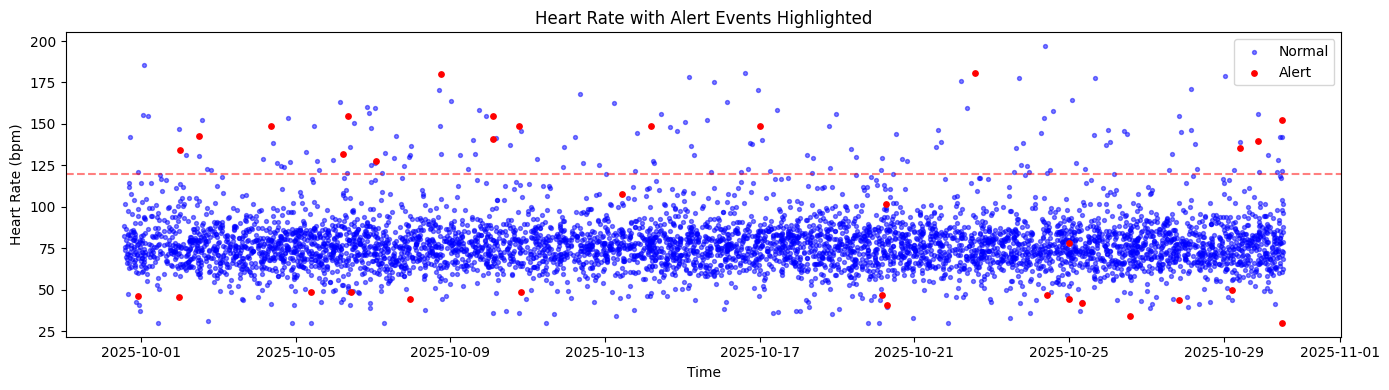

In [152]:
plt.figure(figsize=(14, 4))

# Normal HR points
normal = df_interp[~df_interp['final_alert']]
alerted = df_interp[df_interp['final_alert']]

plt.scatter(
    normal.index,
    normal['heart_rate'],
    color='blue',
    s=8,
    alpha=0.5,
    label='Normal'
)

plt.scatter(
    alerted.index,
    alerted['heart_rate'],
    color='red',
    s=15,
    label='Alert'
)

plt.axhline(120, color='red', linestyle='--', alpha=0.5)

plt.title("Heart Rate with Alert Events Highlighted")
plt.ylabel("Heart Rate (bpm)")
plt.xlabel("Time")
plt.legend()

plt.tight_layout()
plt.show()


# Rule Based Patient Education

In [153]:
education = []

if df_interp['sleep_quality'].iloc[-1] < 0.3:
    education.append("Improve sleep duration and regularity.")

if df_interp['stress_level'].iloc[-1] > 0.7:
    education.append("Stress reduction may improve heart rate and BP.")

if df_interp['steps_count'].iloc[-1] < 2000:
    education.append("Increase daily activity gradually.")

if df_interp['glycemic_risk'].iloc[-1] != "Normal":
    education.append("Dietary review and glucose monitoring advised.")

# Health Events

**Health Events Overlaid on HR**

In [154]:
fig = px.scatter(
    df_interp.reset_index(),
    x='timestamp',
    y='heart_rate',
    color='health_event',
    title="Heart Rate with Health Events Highlighted"
)

fig.update_layout(height=350)
fig.show()


In [155]:
df_monitoring.head()

,timestamp,device_id,patient_id,heart_rate,blood_oxygen,blood_pressure_systolic,blood_pressure_diastolic,glucose_level,body_temperature,respiratory_rate,activity_level,sleep_quality,stress_level,hrv_sdnn,steps_count,calories_burned,health_event
0,2025-09-30 13:06:45.056387,DEVICE_0040,PATIENT_0310,88.7,91.9,178.0,100.0,131.1,97.66,23.3,0.486,0.215,0.778,12.7,2189,2033,3
1,2025-09-30 13:30:45.056387,DEVICE_0078,PATIENT_0147,82.3,96.5,122.0,82.0,57.7,98.89,19.9,0.650,0.671,0.296,58.1,11342,2634,0
2,2025-09-30 13:46:45.056387,DEVICE_0013,PATIENT_0129,101.7,91.3,139.0,102.0,143.4,98.89,26.5,0.490,0.395,0.772,17.2,3456,2157,3
3,2025-09-30 13:48:45.056387,DEVICE_0085,PATIENT_0470,73.9,98.3,121.0,88.0,108.5,98.73,16.5,0.445,0.707,0.339,97.2,8300,1631,0
4,2025-09-30 14:15:45.056387,DEVICE_0055,PATIENT_0245,75.7,93.0,109.0,81.0,109.2,98.74,14.2,0.612,0.844,0.197,64.1,7337,2498,0


# Anomaly Detection

In [156]:
df_ml = df_interp.reset_index().copy()
df_ml["row_id"] = df_ml.index

model_features = (
    df_ml[["row_id", "heart_rate", "activity_level", "hrv_sdnn"]]
    .dropna()
)

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

model_features["hr_anomaly"] = iso_model.fit_predict(
    model_features[["heart_rate", "activity_level", "hrv_sdnn"]]
)
df_ml = df_ml.merge(
    model_features[["row_id", "hr_anomaly"]],
    on="row_id",
    how="left"
)
df_interp = (
    df_ml
    .drop(columns="row_id")
    .set_index("timestamp")
)


In [158]:
#visualize anomalies
fig = px.scatter(
    df_interp.reset_index(),
    x="timestamp",
    y="heart_rate",
    color="hr_anomaly",
    title="Heart Rate Anomaly Detection (Isolation Forest)",
    labels={"hr_anomaly": "Anomaly (-1 = yes)"}
)

fig.update_layout(height=350, hovermode="x unified")
fig.show()
